STFT parameters: nperseg=16 samples (100.0ms), noverlap=12 samples


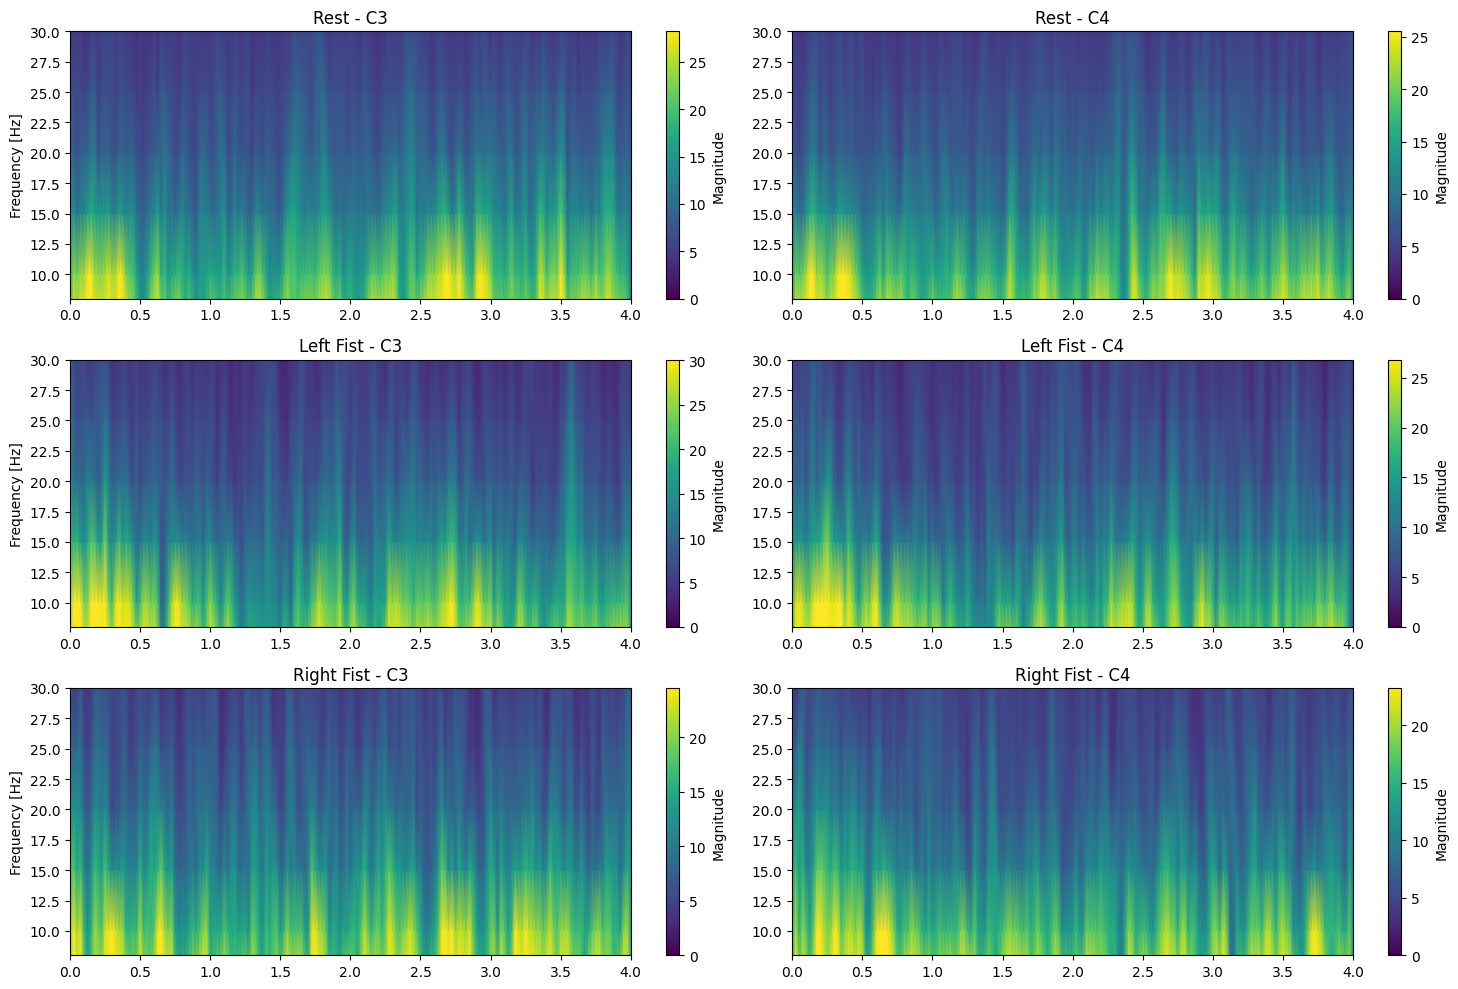

Laterality Index (Left Fist): 0.09
Laterality Index (Right Fist): 0.05


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from pyedflib import highlevel

# Load the EDF file
path = "S001R03.edf"
signals, signal_headers, header = highlevel.read_edf(path)
fs = signal_headers[0]['sample_frequency']  # Sampling rate (Hz)
channel_names = [h['label'] for h in signal_headers]  # List of channel names

# Find indices of C3 and C4
c3_idx = channel_names.index('C3..')
c4_idx = channel_names.index('C4..')
c3_signal = signals[c3_idx, :]
c4_signal = signals[c4_idx, :]

# Filtering functions
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop')
    return filtfilt(b, a, data)

# Apply filters
c3_filtered = bandpass_filter(c3_signal, 0.5, 40, fs)
c4_filtered = bandpass_filter(c4_signal, 0.5, 40, fs)
c3_filtered = notch_filter(c3_filtered, 50, fs)
c4_filtered = notch_filter(c4_filtered, 50, fs)

# Parse annotations (manually from your description)
annotations = [
    (0.00, 4.2, 'T0'), (4.20, 4.1, 'T2'), (8.30, 4.2, 'T0'), (12.50, 4.1, 'T1'),
    (16.60, 4.2, 'T0'), (20.80, 4.1, 'T1'), (24.90, 4.2, 'T0'), (29.10, 4.1, 'T2'),
    (33.20, 4.2, 'T0'), (37.40, 4.1, 'T2'), (41.50, 4.2, 'T0'), (45.70, 4.1, 'T1'),
    (49.80, 4.2, 'T0'), (54.00, 4.1, 'T1'), (58.10, 4.2, 'T0'), (62.30, 4.1, 'T2'),
    (66.40, 4.2, 'T0'), (70.60, 4.1, 'T1'), (74.70, 4.2, 'T0'), (78.90, 4.1, 'T2'),
    (83.00, 4.2, 'T0'), (87.20, 4.1, 'T2'), (91.30, 4.2, 'T0'), (95.50, 4.1, 'T1'),
    (99.60, 4.2, 'T0'), (103.80, 4.1, 'T1'), (107.90, 4.2, 'T0'), (112.10, 4.1, 'T2'),
    (116.20, 4.2, 'T0'), (120.40, 4.1, 'T1')
]

# Convert annotations to events array (sample numbers)
events = []
for onset, duration, description in annotations:
    sample = int(onset * fs)
    events.append([sample, 0, description])

# Create event dictionary
event_dict = {'T0': 'Rest', 'T1': 'Left Fist', 'T2': 'Right Fist'}

# STFT parameters for ~200ms resolution
# nperseg: Number of samples in a 200ms window
window_duration = 0.1  # seconds
nperseg = int(fs * window_duration)
# noverlap: Overlap can be 50% or 75% for better resolution without losing information
noverlap = int(nperseg * 0.75)  # 75% overlap is good for more time resolution
nfft = nperseg * 2 # Zero padding, usually 2 times nperseg for better frequency resolution

print(f"STFT parameters: nperseg={nperseg} samples ({window_duration*1000}ms), noverlap={noverlap} samples")


# Function to compute STFT for epochs
def compute_epoch_stft(data, events, event_type, tmin=0, tmax=4, fs=160):
    """Compute STFT for specific event type"""
    # Get all events of this type
    event_samples = [e[0] for e in events if e[2] == event_type]
    
    # Initialize list to store STFT results
    stft_results = []
    
    for sample in event_samples:
        # Extract epoch
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        # Compute STFT
        # f, t, Zxx are already computed with the desired resolution based on nperseg and noverlap
        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        stft_results.append(np.abs(Zxx))  # Store magnitude
        
    # Average across trials
    # Ensure that stft_results is not empty before attempting to average
    if stft_results:
        avg_stft = np.mean(stft_results, axis=0)
    else:
        # Handle case where no events of event_type are found
        # You might return None or raise an error, depending on desired behavior
        print(f"No epochs found for event type: {event_type}")
        return None, None, None # Return None for f, t, avg_stft

    return f, t, avg_stft

# Compute STFT for each condition (C3 and C4)
conditions = ['T0', 'T1', 'T2']
results = {}

for cond in conditions:
    # C3 results
    f, t, c3_stft = compute_epoch_stft(c3_filtered, events, cond, fs=fs) # Pass fs
    # C4 results
    _, _, c4_stft = compute_epoch_stft(c4_filtered, events, cond, fs=fs) # Pass fs
    
    # Only store results if STFT computation was successful
    if c3_stft is not None and c4_stft is not None:
        results[cond] = {
            'frequencies': f,
            'times': t,
            'C3': c3_stft,
            'C4': c4_stft
        }
    else:
        print(f"Skipping visualization for condition {cond} due to missing STFT data.")

# Visualization
plt.figure(figsize=(15, 10))

for i, cond in enumerate(conditions):
    if cond in results: # Only plot if data exists for the condition
        # Plot C3
        plt.subplot(3, 2, i*2+1)
        plt.pcolormesh(results[cond]['times'], results[cond]['frequencies'], 
                       results[cond]['C3'], shading='gouraud', vmin=0, 
                       vmax=np.percentile(results[cond]['C3'], 95))
        plt.colorbar(label='Magnitude')
        plt.title(f'{event_dict[cond]} - C3')
        plt.ylabel('Frequency [Hz]')
        plt.ylim([8, 30])  # Focus on mu and beta bands
        
        # Plot C4
        plt.subplot(3, 2, i*2+2)
        plt.pcolormesh(results[cond]['times'], results[cond]['frequencies'], 
                       results[cond]['C4'], shading='gouraud', vmin=0, 
                       vmax=np.percentile(results[cond]['C4'], 95))
        plt.colorbar(label='Magnitude')
        plt.title(f'{event_dict[cond]} - C4')
        plt.ylim([8, 30])  # Focus on mu and beta bands

plt.tight_layout()
plt.show()

# Compute Laterality Index (LI) for motor imagery tasks
def laterality_index(c3_power, c4_power):
    """Compute (C3 - C4)/(C3 + C4)"""
    return (c3_power - c4_power) / (c3_power + c4_power + 1e-10)  # Small constant to avoid division by zero

# Focus on mu band (8-13 Hz) during movement (1-3s after onset)
# Ensure 'T1' and 'T2' are in results before accessing
if 'T1' in results and 'T2' in results:
    mu_band = (results['T1']['frequencies'] >= 8) & (results['T1']['frequencies'] <= 13)
    movement_window = (results['T1']['times'] >= 1) & (results['T1']['times'] <= 3)

    # Compute LI for left and right fist movements
    li_left = laterality_index(
        np.mean(results['T1']['C3'][mu_band][:, movement_window]),
        np.mean(results['T1']['C4'][mu_band][:, movement_window])
    )

    li_right = laterality_index(
        np.mean(results['T2']['C3'][mu_band][:, movement_window]),
        np.mean(results['T2']['C4'][mu_band][:, movement_window])
    )

    print(f"Laterality Index (Left Fist): {li_left:.2f}")
    print(f"Laterality Index (Right Fist): {li_right:.2f}")

    # Expected pattern:
    # Left fist should show negative LI (C4 > C3)
    # Right fist should show positive LI (C3 > C4)
else:
    print("Cannot compute Laterality Index: Missing data for 'T1' or 'T2' conditions.")

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from pyedflib import highlevel
import os # Importar o módulo os para criar diretórios e gerenciar caminhos

# Load the EDF file
path = "S001R03.edf"
signals, signal_headers, header = highlevel.read_edf(path)
fs = signal_headers[0]['sample_frequency']  # Sampling rate (Hz)
channel_names = [h['label'] for h in signal_headers]  # List of channel names

# Find indices of C3 and C4
c3_idx = channel_names.index('C3..')
c4_idx = channel_names.index('C4..')
c3_signal = signals[c3_idx, :]
c4_signal = signals[c4_idx, :]

# Filtering functions
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop')
    return filtfilt(b, a, data)

# Apply filters
c3_filtered = bandpass_filter(c3_signal, 0.5, 40, fs)
c4_filtered = bandpass_filter(c4_signal, 0.5, 40, fs)
c3_filtered = notch_filter(c3_filtered, 50, fs)
c4_filtered = notch_filter(c4_filtered, 50, fs)

# Parse annotations (manually from your description)
annotations = [
    (0.00, 4.2, 'T0'), (4.20, 4.1, 'T2'), (8.30, 4.2, 'T0'), (12.50, 4.1, 'T1'),
    (16.60, 4.2, 'T0'), (20.80, 4.1, 'T1'), (24.90, 4.2, 'T0'), (29.10, 4.1, 'T2'),
    (33.20, 4.2, 'T0'), (37.40, 4.1, 'T2'), (41.50, 4.2, 'T0'), (45.70, 4.1, 'T1'),
    (49.80, 4.2, 'T0'), (54.00, 4.1, 'T1'), (58.10, 4.2, 'T0'), (62.30, 4.1, 'T2'),
    (66.40, 4.2, 'T0'), (70.60, 4.1, 'T1'), (74.70, 4.2, 'T0'), (78.90, 4.1, 'T2'),
    (83.00, 4.2, 'T0'), (87.20, 4.1, 'T2'), (91.30, 4.2, 'T0'), (95.50, 4.1, 'T1'),
    (99.60, 4.2, 'T0'), (103.80, 4.1, 'T1'), (107.90, 4.2, 'T0'), (112.10, 4.1, 'T2'),
    (116.20, 4.2, 'T0'), (120.40, 4.1, 'T1')
]

# Convert annotations to events array (sample numbers)
events = []
for onset, duration, description in annotations:
    sample = int(onset * fs)
    events.append([sample, 0, description])

# Create event dictionary (original: 'T0': 'Rest', 'T1': 'Left Fist', 'T2': 'Right Fist')
# Mapeamento para nomes de pastas desejados
event_dict = {'T0': 'rest', 'T1': 'left', 'T2': 'right'} # Alterado para nomes de pastas em minúsculas

# Definir as durações de janela a serem testadas (em segundos)
# Convertendo para milissegundos para os nomes das pastas
window_durations_ms = [50, 100, 200, 400, 600, 800, 1000]
window_durations_sec = [ms / 1000.0 for ms in window_durations_ms]

# Função para computar STFT para cada época individualmente
def compute_individual_epoch_stft(data, events, event_type, tmin, tmax, fs,
                                  nperseg, noverlap, nfft):
    """
    Compute STFT for each individual epoch of a specific event type.
    Returns a list of (f, t, Zxx) for each epoch.
    """
    event_samples = [e[0] for e in events if e[2] == event_type]
    
    individual_stft_data = []
    
    for i, sample in enumerate(event_samples):
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        # Check if epoch is valid (not empty)
        if len(epoch) == 0:
            print(f"Warning: Epoch {i+1} for {event_type} is empty. Skipping.")
            continue

        # Certifique-se de que o tamanho da época é suficiente para nperseg
        if len(epoch) < nperseg:
            print(f"Warning: Epoch {i+1} for {event_type} (length {len(epoch)}) is shorter than nperseg ({nperseg}). Skipping STFT for this epoch.")
            continue

        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        individual_stft_data.append({'epoch_idx': i, 'frequencies': f, 'times': t, 'magnitude': np.abs(Zxx)})
        
    return individual_stft_data

# Loop sobre cada duração de janela
for i, window_duration_sec in enumerate(window_durations_sec):
    current_window_ms = window_durations_ms[i]
    
    # Recalcular parâmetros da STFT para a duração de janela atual
    nperseg = int(fs * window_duration_sec)
    noverlap = int(nperseg * 0.75)  # 75% overlap
    nfft = nperseg * 2 # Zero padding

    # Garante que nperseg e noverlap sejam pelo menos 1
    nperseg = max(1, nperseg)
    noverlap = min(noverlap, nperseg - 1) # noverlap deve ser menor que nperseg

    print(f"\n--- Processando Janela de {current_window_ms}ms ---")
    print(f"STFT parameters: nperseg={nperseg} samples, noverlap={noverlap} samples")

    # Diretório base para a duração da janela atual
    base_output_dir = f"spectrograms_{current_window_ms}ms"
    os.makedirs(base_output_dir, exist_ok=True) # Cria o diretório base se não existir

    # Compute STFT for each condition and epoch
    conditions = ['T0', 'T1', 'T2']
    all_epoch_stfts = {} # Para armazenar os resultados de cada época

    for cond in conditions:
        print(f"  Processando condição: {event_dict[cond]}")
        c3_epoch_data = compute_individual_epoch_stft(c3_filtered, events, cond, tmin=0, tmax=4, fs=fs,
                                                      nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        c4_epoch_data = compute_individual_epoch_stft(c4_filtered, events, cond, tmin=0, tmax=4, fs=fs,
                                                      nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        
        all_epoch_stfts[cond] = {'C3': c3_epoch_data, 'C4': c4_epoch_data}

    # Visualization and Saving
    for cond in conditions:
        c3_data = all_epoch_stfts[cond]['C3']
        c4_data = all_epoch_stfts[cond]['C4']

        # Criar a subpasta para o tipo de evento (ex: 'rest', 'left', 'right')
        event_type_dir = os.path.join(base_output_dir, event_dict[cond])
        os.makedirs(event_type_dir, exist_ok=True)
        print(f"  Salvando em: {event_type_dir}")

        for j in range(len(c3_data)): # Assume que C3 e C4 têm o mesmo número de épocas
            epoch_idx = c3_data[j]['epoch_idx']
            f_c3, t_c3, Zxx_c3 = c3_data[j]['frequencies'], c3_data[j]['times'], c3_data[j]['magnitude']
            f_c4, t_c4, Zxx_c4 = c4_data[j]['frequencies'], c4_data[j]['times'], c4_data[j]['jmagnitude']

            fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True) # Criar uma figura para cada época

            # Plot C3
            im1 = axes[0].pcolormesh(t_c3, f_c3, Zxx_c3, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c3, 95))
            fig.colorbar(im1, ax=axes[0], label='Magnitude')
            axes[0].set_title(f'{event_dict[cond].capitalize()} - Época {epoch_idx+1} - C3')
            axes[0].set_ylabel('Frequência [Hz]')
            axes[0].set_xlabel('Tempo [s]')
            axes[0].set_ylim([8, 30])  # Foco nas bandas mu e beta
            
            # Plot C4
            im2 = axes[1].pcolormesh(t_c4, f_c4, Zxx_c4, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c4, 95))
            fig.colorbar(im2, ax=axes[1], label='Magnitude')
            axes[1].set_title(f'{event_dict[cond].capitalize()} - Época {epoch_idx+1} - C4')
            axes[1].set_xlabel('Tempo [s]')
            axes[1].set_ylim([8, 30])  # Foco nas bandas mu e beta

            plt.tight_layout()
            
            # Salvar o espectrograma na subpasta correta
            filename = f"epoch_{epoch_idx+1}.png" # Nome do arquivo na subpasta
            full_path = os.path.join(event_type_dir, filename)
            plt.savefig(full_path)
            plt.close(fig) # Fechar a figura para liberar memória

print(f"\nProcessamento concluído. Todos os espectrogramas foram salvos nas pastas correspondentes.")

STFT parameters: nperseg=32 samples (200.0ms), noverlap=24 samples

Processing condition: Rest

Processing condition: Left

Processing condition: Right
Criando diretório: spectrograms_by_event_type\rest
Criando diretório: spectrograms_by_event_type\left
Criando diretório: spectrograms_by_event_type\right

Todos os espectrogramas foram salvos no diretório: spectrograms_by_event_type, divididos por tipo de evento.
STFT parameters: nperseg=32 samples (200.0ms), noverlap=24 samples

Processing condition: Rest

Processing condition: Left

Processing condition: Right

Todos os espectrogramas foram salvos na pasta: spectrograms_per_epoch


In [2]:
import numpy as np
from scipy import signal
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split

def extract_features(data, events, fs, nperseg=256, noverlap=128):
    """
    Extract time-frequency features from EEG data
    Returns: X (features), y (labels), feature_names
    """
    # Frequency bands of interest
    bands = {
        'delta': (0.5, 4),
        'theta': (4, 8),
        'alpha': (8, 13),
        'beta': (13, 30),
        'gamma': (30, 40)
    }
    
    # Event window parameters
    tmin, tmax = 0.5, 3.5  # Analyze 0.5-3.5s after event onset
    
    X = []
    y = []
    feature_names = []
    
    for sample, _, event_type in events:
        # Extract epoch
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        # Compute STFT
        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                               nperseg=nperseg, noverlap=noverlap)
        power = np.abs(Zxx) ** 2  # Power spectrum
        
        # Initialize feature vector for this epoch
        epoch_features = []
        
        # 1. Band power features
        for band_name, (fmin, fmax) in bands.items():
            band_mask = (f >= fmin) & (f <= fmax)
            band_power = power[band_mask, :].mean(axis=0)  # Mean across frequency bins
            epoch_features.extend(band_power)
            feature_names.extend([f'{band_name}_power_{i}' for i in range(len(band_power))])
        
        # 2. Statistical features
        mean_power = power.mean(axis=1)
        std_power = power.std(axis=1)
        
        epoch_features.extend(mean_power)
        epoch_features.extend(std_power)
        feature_names.extend([f'mean_power_{i}' for i in range(len(mean_power))])
        feature_names.extend([f'std_power_{i}' for i in range(len(std_power))])
        
        X.append(epoch_features)
        y.append(event_type)
    
    return np.array(X), np.array(y), feature_names

# Extract features for C3 and C4
X_c3, y, feature_names = extract_features(c3_filtered, events, fs)
X_c4, _, _ = extract_features(c4_filtered, events, fs)

# Combine C3 and C4 features
X_combined = np.concatenate([X_c3, X_c4], axis=1)
combined_feature_names = (
    [f'C3_{name}' for name in feature_names] + 
    [f'C4_{name}' for name in feature_names]
)

# Alternative: Laterality features (C3-C4)
X_laterality = X_c3 - X_c4
laterality_feature_names = [f'Laterality_{name}' for name in feature_names]

In [3]:
# Convert labels to numerical values
label_map = {'T0': 0, 'T1': 1, 'T2': 2}
y_numeric = np.array([label_map[label] for label in y])

# Normalize features
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X_combined)

# Alternative normalization: log transform for power features
# X_normalized = np.log1p(X_combined)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_numeric, test_size=0.2, random_state=42, stratify=y_numeric
)

In [4]:
from sklearn.decomposition import PCA

# Apply PCA to reduce dimensionality
pca = PCA(n_components=0.95)  # Keep 95% of variance
X_train_pca = pca.fit_transform(X_train)
X_test_pca = pca.transform(X_test)

print(f"Reduced from {X_train.shape[1]} to {X_train_pca.shape[1]} features")

Reduced from 566 to 20 features


In [5]:
def create_spectrogram_dataset(data, events, fs, nperseg=256, noverlap=128):
    """Create 3D spectrogram dataset for CNN input"""
    tmin, tmax = 0.5, 3.5  # Analysis window
    
    spectrograms = []
    labels = []
    
    for sample, _, event_type in events:
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                               nperseg=nperseg, noverlap=noverlap)
        spectrograms.append(np.abs(Zxx))
        labels.append(label_map[event_type])
    
    # Convert to numpy arrays
    X = np.array(spectrograms)
    y = np.array(labels)
    
    # Add channel dimension (for CNN)
    X = X[..., np.newaxis]
    
    return X, y

# Create spectrogram datasets for C3 and C4
X_c3_spec, y_spec = create_spectrogram_dataset(c3_filtered, events, fs)
X_c4_spec, _ = create_spectrogram_dataset(c4_filtered, events, fs)

# Combine channels (for multi-channel CNN input)
X_combined_spec = np.stack([X_c3_spec, X_c4_spec], axis=1)  # Shape: (n_samples, 2, freq_bins, time_points, 1)

# Train-test split
X_train_spec, X_test_spec, y_train_spec, y_test_spec = train_test_split(
    X_combined_spec, y_spec, test_size=0.2, random_state=42, stratify=y_spec
)

In [7]:
from scipy.stats import skew, kurtosis  # Add this import at the top of your file

def add_time_features(X, data, events, fs):
    """Add time-domain statistical features to existing feature matrix"""
    tmin, tmax = 0.5, 3.5
    time_features = []
    
    for sample, _, _ in events:
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        # Calculate time-domain features
        mean = np.mean(epoch)
        std = np.std(epoch)
        epoch_skew = skew(epoch)
        epoch_kurt = kurtosis(epoch)
        rms = np.sqrt(np.mean(epoch**2))  # Root Mean Square
        zero_crossings = ((epoch[:-1] * epoch[1:]) < 0).sum()  # Zero-crossing rate
        
        time_features.append([mean, std, epoch_skew, epoch_kurt, rms, zero_crossings])
    
    return np.concatenate([X, np.array(time_features)], axis=1)

# Usage
X_with_time = add_time_features(X_normalized, c3_filtered, events, fs)

In [8]:
import joblib

# Save feature-based dataset
joblib.dump({
    'X_train': X_train,
    'X_test': X_test,
    'y_train': y_train,
    'y_test': y_test,
    'feature_names': combined_feature_names
}, 'eeg_features_dataset.pkl')

# Save spectrogram dataset
np.savez('eeg_spectrograms.npz',
         X_train=X_train_spec,
         X_test=X_test_spec,
         y_train=y_train_spec,
         y_test=y_test_spec)

In [10]:
import pandas as pd
print(pd.Series(y_numeric).value_counts())

0    15
1     8
2     7
Name: count, dtype: int64


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from pyedflib import highlevel
import os # Importar o módulo os para criar diretórios e gerenciar caminhos

# Load the EDF file
path = "S001R03.edf"
signals, signal_headers, header = highlevel.read_edf(path)
fs = signal_headers[0]['sample_frequency']  # Sampling rate (Hz)
channel_names = [h['label'] for h in signal_headers]  # List of channel names

# Find indices of C3 and C4
c3_idx = channel_names.index('C3..')
c4_idx = channel_names.index('C4..')
c3_signal = signals[c3_idx, :]
c4_signal = signals[c4_idx, :]

# Filtering functions
def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop')
    return filtfilt(b, a, data)

# Apply filters
c3_filtered = bandpass_filter(c3_signal, 0.5, 40, fs)
c4_filtered = bandpass_filter(c4_signal, 0.5, 40, fs)
c3_filtered = notch_filter(c3_filtered, 50, fs)
c4_filtered = notch_filter(c4_filtered, 50, fs)

# Parse annotations (manually from your description)
annotations = [
    (0.00, 4.2, 'T0'), (4.20, 4.1, 'T2'), (8.30, 4.2, 'T0'), (12.50, 4.1, 'T1'),
    (16.60, 4.2, 'T0'), (20.80, 4.1, 'T1'), (24.90, 4.2, 'T0'), (29.10, 4.1, 'T2'),
    (33.20, 4.2, 'T0'), (37.40, 4.1, 'T2'), (41.50, 4.2, 'T0'), (45.70, 4.1, 'T1'),
    (49.80, 4.2, 'T0'), (54.00, 4.1, 'T1'), (58.10, 4.2, 'T0'), (62.30, 4.1, 'T2'),
    (66.40, 4.2, 'T0'), (70.60, 4.1, 'T1'), (74.70, 4.2, 'T0'), (78.90, 4.1, 'T2'),
    (83.00, 4.2, 'T0'), (87.20, 4.1, 'T2'), (91.30, 4.2, 'T0'), (95.50, 4.1, 'T1'),
    (99.60, 4.2, 'T0'), (103.80, 4.1, 'T1'), (107.90, 4.2, 'T0'), (112.10, 4.1, 'T2'),
    (116.20, 4.2, 'T0'), (120.40, 4.1, 'T1')
]

# Convert annotations to events array (sample numbers)
events = []
for onset, duration, description in annotations:
    sample = int(onset * fs)
    events.append([sample, 0, description])

# Create event dictionary (original: 'T0': 'Rest', 'T1': 'Left Fist', 'T2': 'Right Fist')
# Mapeamento para nomes de pastas desejados
event_dict = {'T0': 'rest', 'T1': 'left', 'T2': 'right'} # Alterado para nomes de pastas em minúsculas

# Definir as durações de janela a serem testadas (em segundos)
# Convertendo para milissegundos para os nomes das pastas
window_durations_ms = [50, 100, 200, 400, 600, 800, 1000]
window_durations_sec = [ms / 1000.0 for ms in window_durations_ms]

# Função para computar STFT para cada época individualmente
def compute_individual_epoch_stft(data, events, event_type, tmin, tmax, fs,
                                  nperseg, noverlap, nfft):
    """
    Compute STFT for each individual epoch of a specific event type.
    Returns a list of (f, t, Zxx) for each epoch.
    """
    event_samples = [e[0] for e in events if e[2] == event_type]
    
    individual_stft_data = []
    
    for i, sample in enumerate(event_samples):
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        # Check if epoch is valid (not empty)
        if len(epoch) == 0:
            print(f"Warning: Epoch {i+1} for {event_type} is empty. Skipping.")
            continue

        # Certifique-se de que o tamanho da época é suficiente para nperseg
        if len(epoch) < nperseg:
            print(f"Warning: Epoch {i+1} for {event_type} (length {len(epoch)}) is shorter than nperseg ({nperseg}). Skipping STFT for this epoch.")
            continue

        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        individual_stft_data.append({'epoch_idx': i, 'frequencies': f, 'times': t, 'magnitude': np.abs(Zxx)})
        
    return individual_stft_data

# Loop sobre cada duração de janela
for i, window_duration_sec in enumerate(window_durations_sec):
    current_window_ms = window_durations_ms[i]
    
    # Recalcular parâmetros da STFT para a duração de janela atual
    nperseg = int(fs * window_duration_sec)
    noverlap = int(nperseg * 0.75)  # 75% overlap
    nfft = nperseg * 2 # Zero padding

    # Garante que nperseg e noverlap sejam pelo menos 1
    nperseg = max(1, nperseg)
    noverlap = min(noverlap, nperseg - 1) # noverlap deve ser menor que nperseg

    print(f"\n--- Processando Janela de {current_window_ms}ms ---")
    print(f"STFT parameters: nperseg={nperseg} samples, noverlap={noverlap} samples")

    # Diretório base para a duração da janela atual
    base_output_dir = f"spectrograms_{current_window_ms}ms"
    os.makedirs(base_output_dir, exist_ok=True) # Cria o diretório base se não existir

    # Compute STFT for each condition and epoch
    conditions = ['T0', 'T1', 'T2']
    all_epoch_stfts = {} # Para armazenar os resultados de cada época

    for cond in conditions:
        print(f"  Processando condição: {event_dict[cond]}")
        c3_epoch_data = compute_individual_epoch_stft(c3_filtered, events, cond, tmin=0, tmax=4, fs=fs,
                                                      nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        c4_epoch_data = compute_individual_epoch_stft(c4_filtered, events, cond, tmin=0, tmax=4, fs=fs,
                                                      nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        
        all_epoch_stfts[cond] = {'C3': c3_epoch_data, 'C4': c4_epoch_data}

    # Visualization and Saving
    for cond in conditions:
        c3_data = all_epoch_stfts[cond]['C3']
        c4_data = all_epoch_stfts[cond]['C4']

        # Criar a subpasta para o tipo de evento (ex: 'rest', 'left', 'right')
        event_type_dir = os.path.join(base_output_dir, event_dict[cond])
        os.makedirs(event_type_dir, exist_ok=True)
        print(f"  Salvando em: {event_type_dir}")

        for j in range(len(c3_data)): # Assume que C3 e C4 têm o mesmo número de épocas
            epoch_idx = c3_data[j]['epoch_idx']
            f_c3, t_c3, Zxx_c3 = c3_data[j]['frequencies'], c3_data[j]['times'], c3_data[j]['magnitude']
            f_c4, t_c4, Zxx_c4 = c4_data[j]['frequencies'], c4_data[j]['times'], c4_data[j]['magnitude']

            fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True) # Criar uma figura para cada época

            # Plot C3
            im1 = axes[0].pcolormesh(t_c3, f_c3, Zxx_c3, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c3, 95))
            fig.colorbar(im1, ax=axes[0], label='Magnitude')
            axes[0].set_title(f'{event_dict[cond].capitalize()} - Época {epoch_idx+1} - C3')
            axes[0].set_ylabel('Frequência [Hz]')
            axes[0].set_xlabel('Tempo [s]')
            axes[0].set_ylim([8, 30])  # Foco nas bandas mu e beta
            
            # Plot C4
            im2 = axes[1].pcolormesh(t_c4, f_c4, Zxx_c4, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c4, 95))
            fig.colorbar(im2, ax=axes[1], label='Magnitude')
            axes[1].set_title(f'{event_dict[cond].capitalize()} - Época {epoch_idx+1} - C4')
            axes[1].set_xlabel('Tempo [s]')
            axes[1].set_ylim([8, 30])  # Foco nas bandas mu e beta

            plt.tight_layout()
            
            # Salvar o espectrograma na subpasta correta
            filename = f"epoch_{epoch_idx+1}.png" # Nome do arquivo na subpasta
            full_path = os.path.join(event_type_dir, filename)
            plt.savefig(full_path)
            plt.close(fig) # Fechar a figura para liberar memória

print(f"\nProcessamento concluído. Todos os espectrogramas foram salvos nas pastas correspondentes.")


--- Processando Janela de 50ms ---
STFT parameters: nperseg=8 samples, noverlap=6 samples
  Processando condição: rest
  Processando condição: left
  Processando condição: right
  Salvando em: spectrograms_50ms\rest
  Salvando em: spectrograms_50ms\left
  Salvando em: spectrograms_50ms\right

--- Processando Janela de 100ms ---
STFT parameters: nperseg=16 samples, noverlap=12 samples
  Processando condição: rest
  Processando condição: left
  Processando condição: right
  Salvando em: spectrograms_100ms\rest
  Salvando em: spectrograms_100ms\left
  Salvando em: spectrograms_100ms\right

--- Processando Janela de 200ms ---
STFT parameters: nperseg=32 samples, noverlap=24 samples
  Processando condição: rest
  Processando condição: left
  Processando condição: right
  Salvando em: spectrograms_200ms\rest
  Salvando em: spectrograms_200ms\left
  Salvando em: spectrograms_200ms\right

--- Processando Janela de 400ms ---
STFT parameters: nperseg=64 samples, noverlap=48 samples
  Processand

In [10]:
#TREINAMENDO REDE NEURAL SIMPLES
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, accuracy_score
from sklearn.preprocessing import StandardScaler

from tensorflow.keras.utils import to_categorical  
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, BatchNormalization
from tensorflow.keras.optimizers import Adam


## 1. Prepare the features (using your filtered C3 and C4 data)
def prepare_simple_features(c3_signal, c4_signal, events, fs, tmin=0.5, tmax=3.5):
    """Extract simple band power features"""
    features = []
    labels = []
    
    # Frequency bands to analyze
    bands = {
    'mu': (8, 13),
    'beta_low': (13, 20),
    'beta_high': (20, 30)
    }
    
    for sample, _, event_type in events:
        # Get epoch from both channels
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        c3_epoch = c3_signal[start:end]
        c4_epoch = c4_signal[start:end]
        
        epoch_features = []
        
        # Calculate band power for each channel
        for ch_epoch in [c3_epoch, c4_epoch]:
            # Simple power spectrum (using FFT)
            fft_vals = np.fft.fft(ch_epoch)
            psd = np.abs(fft_vals) ** 2
            freqs = np.fft.fftfreq(len(ch_epoch), 1/fs)
            
            for band_name, (fmin, fmax) in bands.items():
                band_mask = (freqs >= fmin) & (freqs <= fmax)
                band_power = psd[band_mask].mean()
                epoch_features.append(band_power)
        
        # Add asymmetry feature (C3-C4)/(C3+C4) for mu band
        mu_power_c3 = epoch_features[0]  # First feature is C3 mu
        mu_power_c4 = epoch_features[2]  # Third feature is C4 mu
        asymmetry = (mu_power_c3 - mu_power_c4) / (mu_power_c3 + mu_power_c4 + 1e-10)
        epoch_features.append(asymmetry)
        
        features.append(epoch_features)
        labels.append(event_type)
    
    return np.array(features), np.array(labels)

# Extract features
X, y = prepare_simple_features(c3_filtered, c4_filtered, events, fs)

# Convert labels to numeric
label_map = {'T0': 0, 'T1': 1, 'T2': 2}
y_numeric = np.array([label_map[label] for label in y])

# 2. Normalize and split
scaler = StandardScaler()
X_normalized = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_normalized, y_numeric, test_size=0.2, random_state=42, stratify=y_numeric
)

# Convert labels to categorical (one-hot encoding)
y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

# 3. Build a neural network
model = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')  # 3 classes: T0, T1, T2
])

model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

# 4. Train the model
history = model.fit(X_train, y_train_cat, epochs=100, batch_size=8, validation_split=0.2, verbose=1)

# 5. Evaluate
loss, accuracy = model.evaluate(X_test, y_test_cat, verbose=0)
print(f"\nTest Accuracy: {accuracy * 100:.2f}%")

# Predict and print classification report
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Rest', 'Left Fist', 'Right Fist']))

Epoch 1/100


c:\Users\luize\OneDrive\Área de Trabalho\Codes\EEG_Study\venv\lib\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 73ms/step - accuracy: 0.2673 - loss: 1.1410 - val_accuracy: 0.4000 - val_loss: 1.0877
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.4186 - loss: 1.0285 - val_accuracy: 0.4000 - val_loss: 1.1068
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 22ms/step - accuracy: 0.6702 - loss: 0.9689 - val_accuracy: 0.4000 - val_loss: 1.1375
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4137 - loss: 0.9773 - val_accuracy: 0.4000 - val_loss: 1.1692
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.4400 - loss: 0.9993 - val_accuracy: 0.4000 - val_loss: 1.1984
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.6283 - loss: 0.9537 - val_accuracy: 0.4000 - val_loss: 1.2270
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5658 - loss: 0.8842 - val_accuracy: 0.4000 - val_loss: 1.2584
Epoch 8/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step - accuracy: 0.5814 - loss: 0.8743 - val_accuracy: 0.4000 - val_loss: 1.2895
Epoc

c:\Users\luize\OneDrive\Área de Trabalho\Codes\EEG_Study\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luize\OneDrive\Área de Trabalho\Codes\EEG_Study\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
c:\Users\luize\OneDrive\Área de Trabalho\Codes\EEG_Study\venv\lib\site-packages\sklearn\metrics\_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  

In [3]:
import numpy as np
import matplotlib.pyplot as plt
from scipy import signal
from scipy.signal import butter, filtfilt
from pyedflib import EdfReader
from pathlib import Path
import os # Importar o módulo os para criar diretórios e gerenciar caminhos

# --- Funções de Processamento de Dados (Mantidas e Adaptadas) ---

def bandpass_filter(data, lowcut, highcut, fs, order=4):
    nyquist = 0.5 * fs
    low = lowcut / nyquist
    high = highcut / nyquist
    b, a = butter(order, [low, high], btype='band')
    return filtfilt(b, a, data)

def notch_filter(data, notch_freq, fs, quality=30):
    nyquist = 0.5 * fs
    freq = notch_freq / nyquist
    b, a = butter(2, [freq - 0.5/quality, freq + 0.5/quality], btype='bandstop')
    return filtfilt(b, a, data)

def compute_individual_epoch_stft(data, events, event_type, tmin, tmax, fs,
                                  nperseg, noverlap, nfft):
    """
    Compute STFT for each individual epoch of a specific event type.
    Returns a list of dictionaries, each containing (f, t, Zxx) for an epoch.
    """
    event_samples = [e[0] for e in events if e[2] == event_type]
    
    individual_stft_data = []
    
    for i, sample in enumerate(event_samples):
        start = sample + int(tmin * fs)
        end = sample + int(tmax * fs)
        epoch = data[start:end]
        
        # Check if epoch is valid (not empty)
        if len(epoch) == 0:
            print(f"    Warning: Epoch {i+1} for {event_type} is empty. Skipping.")
            continue

        # Ensure epoch is long enough for the STFT window
        if len(epoch) < nperseg:
            print(f"    Warning: Epoch {i+1} for {event_type} (length {len(epoch)}) is shorter than nperseg ({nperseg}). Skipping STFT for this epoch.")
            continue

        f, t, Zxx = signal.stft(epoch, fs=fs, window='hann',
                               nperseg=nperseg, noverlap=noverlap, nfft=nfft)
        individual_stft_data.append({'epoch_idx': i, 'frequencies': f, 'times': t, 'magnitude': np.abs(Zxx)})
        
    return individual_stft_data

# --- Configurações Globais ---

# Pasta contendo os arquivos EDF (ajuste conforme necessário)
# Exemplo: Se seus arquivos estão em 'seu_projeto/data/phisionet_data/S001/'
# E o script está em 'seu_projeto/'
pasta_base_dados = Path('data/phisionet_data/S001') 
registros = ['R04', 'R08', 'R12'] # Arquivos EDF a serem processados
event_dict = {'T0': 'rest', 'T1': 'left', 'T2': 'right'} # Mapeamento para nomes de pastas em minúsculas
epoch_duration_sec = 4 # Duração de cada época em segundos (tmax - tmin)

# Definir as durações de janela da STFT a serem testadas (em milissegundos)
window_durations_ms = [50, 100, 200, 400, 600, 800, 1000]
window_durations_sec = [ms / 1000.0 for ms in window_durations_ms]

# --- Loop Principal para Processamento ---

print("Iniciando o processamento de espectrogramas para múltiplos arquivos e janelas...")

# Loop sobre cada duração de janela da STFT
for i, window_duration_s in enumerate(window_durations_sec):
    current_window_ms = window_durations_ms[i]
    
    # Recalcular parâmetros da STFT para a duração de janela atual
    nperseg = int(fs * window_duration_s)
    # noverlap deve ser menor que nperseg e pode ser 75% para boa resolução temporal
    noverlap = int(nperseg * 0.75)
    nfft = nperseg * 2 # Zero padding

    # Garante que nperseg e noverlap sejam pelo menos 1 e noverlap < nperseg
    nperseg = max(1, nperseg)
    noverlap = min(noverlap, nperseg - 1)
    if nperseg == 1: # Caso nperseg seja 1, noverlap deve ser 0
        noverlap = 0

    print(f"\n--- Processando com Janela de {current_window_ms}ms (nperseg={nperseg}, noverlap={noverlap}) ---")

    # Diretório base para a duração da janela atual (ex: 'spectrograms_50ms')
    base_output_dir_window = f"spectrograms_{current_window_ms}ms"
    os.makedirs(base_output_dir_window, exist_ok=True)

    # Loop sobre cada arquivo EDF
    for registro in registros:
        # Encontrar arquivo .edf correspondente
        edf_file = next(pasta_base_dados.glob(f'*{registro}.edf'), None)
        if not edf_file:
            print(f"  Arquivo {registro}.edf não encontrado em {pasta_base_dados}. Pulando.")
            continue

        print(f"  Processando arquivo: {edf_file.name}")
        
        # Diretório para o arquivo EDF atual dentro da pasta da janela (ex: 'spectrograms_50ms/S001R04')
        file_output_dir = os.path.join(base_output_dir_window, edf_file.stem.replace('.', '_')) # Remove '.edf' e substitui '.' por '_'
        os.makedirs(file_output_dir, exist_ok=True)

        # Carregar dados EDF usando EdfReader
        reader = EdfReader(str(edf_file))
        
        # Obter informações dos sinais
        n_channels = reader.signals_in_file
        signal_labels = reader.getSignalLabels()
        fs = reader.getSampleFrequency(0) # Assumindo mesma taxa de amostragem para todos os canais
        signals_data = np.array([reader.readSignal(c) for c in range(n_channels)])
        
        # Obter canais C3 e C4
        try:
            c3_idx = signal_labels.index('C3..')
            c4_idx = signal_labels.index('C4..')
        except ValueError:
            print(f"    Canais 'C3..' ou 'C4..' não encontrados em {edf_file.name}. Pulando este arquivo.")
            reader.close()
            continue

        c3_signal = signals_data[c3_idx, :]
        c4_signal = signals_data[c4_idx, :]
        
        # Ler anotações diretamente do arquivo EDF
        annotations_onset, annotations_duration, annotations_description = reader.readAnnotations()
        reader.close() # Fechar o reader após ler tudo

        # Converter anotações para formato de eventos (amostras em vez de segundos)
        events = []
        for onset, duration, description in zip(annotations_onset, annotations_duration, annotations_description):
            events.append([int(onset * fs), 0, description])
        
        # Aplicar filtros
        c3_filtered = notch_filter(bandpass_filter(c3_signal, 0.5, 40, fs), 50, fs)
        c4_filtered = notch_filter(bandpass_filter(c4_signal, 0.5, 40, fs), 50, fs)
        
        # Processar condições (T0, T1, T2)
        conditions = ['T0', 'T1', 'T2']
        all_epoch_stfts_for_file = {} # Armazena STFTs para o arquivo atual

        for cond_key in conditions:
            print(f"    Calculando STFT para {event_dict[cond_key].capitalize()}...")
            c3_epoch_data = compute_individual_epoch_stft(c3_filtered, events, cond_key, tmin=0, tmax=epoch_duration_sec, fs=fs,
                                                          nperseg=nperseg, noverlap=noverlap, nfft=nfft)
            c4_epoch_data = compute_individual_epoch_stft(c4_filtered, events, cond_key, tmin=0, tmax=epoch_duration_sec, fs=fs,
                                                          nperseg=nperseg, noverlap=noverlap, nfft=nfft)
            
            all_epoch_stfts_for_file[cond_key] = {'C3': c3_epoch_data, 'C4': c4_epoch_data}

        # Visualização e Salvamento dos espectrogramas para o arquivo atual
        for cond_key in conditions:
            c3_data = all_epoch_stfts_for_file[cond_key]['C3']
            c4_data = all_epoch_stfts_for_file[cond_key]['C4']

            # Criar a subpasta para o tipo de evento (ex: 'rest', 'left', 'right')
            event_type_dir = os.path.join(file_output_dir, event_dict[cond_key])
            os.makedirs(event_type_dir, exist_ok=True)
            print(f"    Salvando espectrogramas em: {event_type_dir}")

            # Iterar sobre cada época individual para plotar e salvar
            for j in range(len(c3_data)): # Assume que C3 e C4 têm o mesmo número de épocas
                epoch_idx = c3_data[j]['epoch_idx']
                f_c3, t_c3, Zxx_c3 = c3_data[j]['frequencies'], c3_data[j]['times'], c3_data[j]['magnitude']
                f_c4, t_c4, Zxx_c4 = c4_data[j]['frequencies'], c4_data[j]['times'], c4_data[j]['magnitude']

                fig, axes = plt.subplots(1, 2, figsize=(12, 5), sharey=True) # Criar uma figura para cada época

                # Plot C3
                im1 = axes[0].pcolormesh(t_c3, f_c3, Zxx_c3, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c3, 95))
                fig.colorbar(im1, ax=axes[0], label='Magnitude')
                axes[0].set_title(f'{event_dict[cond_key].capitalize()} - Época {epoch_idx+1} - C3')
                axes[0].set_ylabel('Frequência [Hz]')
                axes[0].set_xlabel('Tempo [s]')
                axes[0].set_ylim([8, 30]) # Foco nas bandas mu e beta
                
                # Plot C4
                im2 = axes[1].pcolormesh(t_c4, f_c4, Zxx_c4, shading='gouraud', vmin=0, vmax=np.percentile(Zxx_c4, 95))
                fig.colorbar(im2, ax=axes[1], label='Magnitude')
                axes[1].set_title(f'{event_dict[cond_key].capitalize()} - Época {epoch_idx+1} - C4')
                axes[1].set_xlabel('Tempo [s]')
                axes[1].set_ylim([8, 30]) # Foco nas bandas mu e beta

                plt.tight_layout()
                
                # Salvar o espectrograma na subpasta correta
                filename = f"epoch_{epoch_idx+1}.png" # Nome do arquivo na subpasta
                full_path = os.path.join(event_type_dir, filename)
                plt.savefig(full_path)
                plt.close(fig) # Fechar a figura para liberar memória

print(f"\nProcessamento concluído. Todos os espectrogramas foram salvos na estrutura de diretórios especificada.")

Iniciando o processamento de espectrogramas para múltiplos arquivos e janelas...

--- Processando com Janela de 50ms (nperseg=8, noverlap=6) ---
  Processando arquivo: S001R04.edf
    Calculando STFT para Rest...
    Calculando STFT para Left...
    Calculando STFT para Right...
    Salvando espectrogramas em: spectrograms_50ms\S001R04\rest
    Salvando espectrogramas em: spectrograms_50ms\S001R04\left
    Salvando espectrogramas em: spectrograms_50ms\S001R04\right
  Processando arquivo: S001R08.edf
    Calculando STFT para Rest...
    Calculando STFT para Left...
    Calculando STFT para Right...
    Salvando espectrogramas em: spectrograms_50ms\S001R08\rest
    Salvando espectrogramas em: spectrograms_50ms\S001R08\left
    Salvando espectrogramas em: spectrograms_50ms\S001R08\right
  Processando arquivo: S001R12.edf
    Calculando STFT para Rest...
    Calculando STFT para Left...
    Calculando STFT para Right...
    Salvando espectrogramas em: spectrograms_50ms\S001R12\rest
    Sal